# Baseline модели для прогнозирования продаж Favorita

## Протокол валидации

Для оценки качества моделей используем валидацию на **2 последних неделях обучающих данных** (15-31 августа 2017). 

**Обоснование:**
- Тестовые данные в соревновании — это 2 недели после окончания тренировочного периода
- Валидация на аналогичном по длительности периоде непосредственно перед тестом дает наиболее реалистичную оценку того, как модель поведет себя на реальных стовых данных
- Позволяет избежать Lookahead bias и проверяет способность модели к обобщению на ближайшее будущее

In [1]:
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsforecast.models import AutoETS

sys.path.append('..')
from src.models.hierarchical_pipeline import HierarchicalForecaster
from src.models.naive_seasonal import NaiveSeasonal
from src.models.sf_adapter import StatsForecastAdapter
from src.utils.metrics import nwrmsle

In [2]:
RAW_DATA_DIR = r"..\data\raw_data"
PREP_DATA_DIR = r"..\data\prepared_data"

In [3]:
train = pd.read_parquet(os.path.join(PREP_DATA_DIR, "train_optimized.parquet"))
items = pd.read_csv(os.path.join(RAW_DATA_DIR, "items.csv"))
stores = pd.read_csv(os.path.join(RAW_DATA_DIR, "stores.csv"))

## Подготовка данных

Создаем три среза:
- Обучающая выборка: все данные до 29 июля 2017
- Валидационная выборка: 30 июля-15 августа 2017

In [ ]:
item_weights = items.set_index('item_nbr')['perishable'].to_dict()
item_weights = {k: 1.25 if v == 1 else 1.0 for k, v in item_weights.items()}

train_end_date = pd.Timestamp('2017-07-29')
val_end_date = pd.Timestamp('2017-08-14')

train_data = train[train['date'] <= train_end_date].copy()
val_data = train[(train['date'] > train_end_date) & (train['date'] <= val_end_date)].copy()
val_data['weight'] = val_data['item_nbr'].map(item_weights).fillna(1.0)

print(f"Train: {len(train_data)} записей")
print(f"Val: {len(val_data)} записей")
print(f"Уникальных пар в train: {train_data.groupby(['store_nbr', 'item_nbr']).ngroups}")

Train: 940591 записей
Val: 1686025 записей
Уникальных пар в train: 143209


# Константные предсказания

In [5]:
# 1. Константа 0
zero_pred = np.zeros(len(val_data))
zero_score = nwrmsle(
    val_data['unit_sales'].values, 
    zero_pred, 
    val_data['weight'].values
)
print(f"Константа 0: {zero_score:.6f}")

# 2. Константа (глобальное среднее)
global_mean = train_data['unit_sales'].mean()
mean_pred = np.full(len(val_data), global_mean)
mean_score = nwrmsle(
    val_data['unit_sales'].values, 
    mean_pred, 
    val_data['weight'].values
)
print(f"Глобальное среднее ({global_mean:.2f}): {mean_score:.6f}")

Константа 0: 1.916219
Глобальное среднее (8.14): 1.007576


## Baseline 1: Naive Seasonal (период = 7 дней)

Самая простая модель: прогноз на основе последней известной недели.
Для каждой пары магазин-товар берем последние 7 дней продаж и повторяем их.

In [6]:
# Группируем данные по парам магазин-товар
train_pairs = train_data.groupby(['store_nbr', 'item_nbr'])

# Словари для хранения прогнозов
naive_predictions = []

In [9]:
total_pairs = train_data.groupby(['store_nbr', 'item_nbr']).ngroups

In [13]:
start_time = time.time()
update_step = total_pairs // 10
next_update = update_step

# Предварительные расчеты
val_start_date = val_data['date'].min()
forecast_horizon = 16

# Группируем val_data
val_grouped = val_data.groupby(['store_nbr', 'item_nbr'])
val_pairs_set = set(val_grouped.groups.keys())

# Создаем словарь с данными валидации
val_dict = {}
for (store, item), group in val_grouped:
    val_dict[(store, item)] = group.sort_values('date').to_dict('records')

# Преобразуем даты в индексы
val_dates = sorted(val_data['date'].unique())
date_to_idx = {date: i for i, date in enumerate(val_dates)}

naive_predictions = []

for idx, ((store, item), group) in enumerate(train_pairs):
    # Прогресс
    if idx >= next_update:
        pct_done = (idx / total_pairs) * 100
        elapsed = time.time() - start_time
        if idx > 0:
            eta = (elapsed / idx) * (total_pairs - idx)
            print(f"Прогресс: {pct_done:.1f}% ({idx}/{total_pairs}), "
                  f"прошло: {elapsed:.1f}s, осталось: {eta:.1f}s")
        next_update += update_step
    
    # Проверяем, есть ли эта пара в валидации
    if (store, item) not in val_dict:
        continue
    
    # Получаем данные валидации
    val_rows = val_dict[(store, item)]
    
    # Получаем временной ряд
    y = group.sort_values('date')['unit_sales'].values
    
    if len(y) >= 7:
        # Прогноз через numpy (быстро)
        last_season = y[-7:]
        n_repeats = (forecast_horizon // 7) + 1
        forecast = np.tile(last_season, n_repeats)[:forecast_horizon]
        
        # Добавляем все записи разом
        for row in val_rows:
            day_offset = date_to_idx[row['date']]
            naive_predictions.append({
                'store_nbr': store,
                'item_nbr': item,
                'date': row['date'],
                'actual': row['unit_sales'],
                'predicted': forecast[day_offset],
                'weight': row['weight']
            })
    else:
        # Нулевой прогноз
        for row in val_rows:
            naive_predictions.append({
                'store_nbr': store,
                'item_nbr': item,
                'date': row['date'],
                'actual': row['unit_sales'],
                'predicted': 0,
                'weight': row['weight']
            })

naive_results = pd.DataFrame(naive_predictions)

print(f"Обработка завершена! Всего пар: {total_pairs}, время: {time.time() - start_time:.1f}s")

Прогресс: 5.0% (7825/156500), прошло: 102.9s, осталось: 1954.3s
Прогресс: 10.0% (15650/156500), прошло: 104.5s, осталось: 940.5s
Прогресс: 15.0% (23475/156500), прошло: 106.1s, осталось: 601.4s
Прогресс: 20.0% (31300/156500), прошло: 107.8s, осталось: 431.0s
Прогресс: 25.0% (39125/156500), прошло: 110.8s, осталось: 332.5s
Прогресс: 30.0% (46950/156500), прошло: 112.4s, осталось: 262.3s
Прогресс: 35.0% (54775/156500), прошло: 114.0s, осталось: 211.8s
Прогресс: 40.0% (62600/156500), прошло: 115.6s, осталось: 173.5s
Прогресс: 45.0% (70425/156500), прошло: 117.2s, осталось: 143.3s
Прогресс: 50.0% (78250/156500), прошло: 118.8s, осталось: 118.8s
Прогресс: 55.0% (86075/156500), прошло: 120.4s, осталось: 98.5s
Прогресс: 60.0% (93900/156500), прошло: 122.0s, осталось: 81.3s
Прогресс: 65.0% (101725/156500), прошло: 123.6s, осталось: 66.6s
Прогресс: 70.0% (109550/156500), прошло: 125.2s, осталось: 53.7s
Прогресс: 75.0% (117375/156500), прошло: 126.8s, осталось: 42.3s
Прогресс: 80.0% (125200/1565

In [14]:
naive_score = nwrmsle(
    naive_results['actual'].values, 
    naive_results['predicted'].values,
    naive_results['weight'].values
)
print(f"Naive Seasonal NWRMSLE: {naive_score:.6f}")

Naive Seasonal NWRMSLE: 0.711998


## Baseline 2: AutoETS

Автоматический Exponential Smoothing (ETS) модель, которая подбирает параметры тренда и сезонности.

In [15]:
train_data = train[train['date'] <= train_end_date].copy()
val_data = train[(train['date'] > train_end_date) & (train['date'] <= val_end_date)].copy()
val_data['weight'] = val_data['item_nbr'].map(item_weights).fillna(1.0)

In [16]:
hier_forecaster = HierarchicalForecaster(stores, items)

In [17]:
aggregated_series = hier_forecaster.create_hierarchy(train_data)

Создание иерархии...
  Всего уникальных товаров: 4000
  Всего уникальных магазинов: 54
  Средние продажи total: 8.49
Пропорции вычислены:
  Средние продажи (total): 8.50
  Уникальных store_proportions: 54
  Уникальных item_proportions: 57880
  Total: 1213 дней
  By cluster: 17 кластеров
  By cluster+family: 551 групп


In [18]:
print("\nАгрегированные ряды:")
for level_name, level_data in aggregated_series.items():
    if level_name == 'total':
        print(f"  {level_name}: {len(level_data)} дней, сумма продаж: {level_data['total_sales'].sum():.0f}")
    elif level_name == 'by_cluster':
        print(f"  {level_name}: {level_data['cluster'].nunique()} кластеров, записей: {len(level_data)}")
    elif level_name == 'by_cluster_family':
        n_groups = level_data.groupby(['cluster', 'family']).ngroups
        print(f"  {level_name}: {n_groups} групп, записей: {len(level_data)}")


Агрегированные ряды:
  total: 1213 дней, сумма продаж: 10300
  by_cluster: 17 кластеров, записей: 20423
  by_cluster_family: 551 групп, записей: 569805


In [19]:
def create_ets_adapter(season_length=7):
    """Фабрика для создания адаптеров AutoETS"""
    return StatsForecastAdapter(
        model_class=AutoETS,
        model_params={'season_length': season_length}
    )

# Использование
hier_forecaster.fit_aggregated(
    model_class=create_ets_adapter,
    model_params={'season_length': 7},
    max_history=90
)

Обучение агрегированных моделей...
  Уровень Total...
  Уровень Clusters...
  Уровень Cluster+Family...
    Обработано 100/551 групп
    Обработано 200/551 групп
    Обработано 300/551 групп
    Обработано 400/551 групп
    Обработано 500/551 групп
Обучено моделей:
  Total: 1
  Clusters: 17
  Cluster+Family: 549


In [ ]:
# Делаем прогнозы на агрегированных уровнях
start_date = val_data['date'].min()
horizon = (val_data['date'].max() - val_data['date'].min()).days + 1

forecasts = hier_forecaster.predict_aggregated(
    horizon=horizon,
    start_date=start_date
)

Горизонт прогноза: 16 дней (с 2017-07-30 00:00:00 по 2017-08-14 00:00:00)
Прогнозирование на 16 дней...
  Всего кластеров: 17
  Всего cluster+family: 549


In [21]:
# Получаем все уникальные пары из валидации
val_pairs = list(val_data.groupby(['store_nbr', 'item_nbr']).groups.keys())
print(f"Всего уникальных пар в валидации: {len(val_pairs)}")

Всего уникальных пар в валидации: 146894


In [22]:
# Дизагрегируем прогнозы до уровня магазин-товар
start_time = time.time()

val_predictions = hier_forecaster.disaggregate_to_store_item(
    forecasts=forecasts,
    test_pairs=val_pairs
)

elapsed = time.time() - start_time
print(f"Дизагрегация завершена за {elapsed:.1f} секунд")
print(f"Получено прогнозов: {len(val_predictions)}")

Дизагрегация прогнозов до уровня магазин-товар...
  Средние продажи (total): 8.50
  Форма total прогноза: (16,)
  Прогресс: 0.0% (0/146894)
  Прогресс: 10.0% (14689/146894)
  Прогресс: 20.0% (29378/146894)
  Прогресс: 30.0% (44067/146894)
  Прогресс: 40.0% (58756/146894)
  Прогресс: 50.0% (73445/146894)
  Прогресс: 60.0% (88134/146894)
  Прогресс: 70.0% (102823/146894)
  Прогресс: 80.0% (117512/146894)
  Прогресс: 90.0% (132201/146894)
  Прогресс: 100.0% (146890/146894)
  Дизагрегация завершена. Всего прогнозов: 2350304
Дизагрегация завершена за 298.6 секунд
Получено прогнозов: 2350304


In [ ]:
# Мерджим с actual для оценки
print("Оценка качества...")
val_with_pred = val_data.merge(
    val_predictions[['store_nbr', 'item_nbr', 'date', 'predicted']],
    on=['store_nbr', 'item_nbr', 'date'],
    how='left'
)

# Проверим, сколько записей не получили прогноз
missing_pred = val_with_pred['predicted'].isna().sum()
if missing_pred > 0:
    print(f"Предупреждение: {missing_pred} записей ({missing_pred/len(val_with_pred)*100:.2f}%) без прогноза")
    val_with_pred['predicted'] = val_with_pred['predicted'].fillna(0)


Оценка качества...


In [ ]:
# Считаем метрику
score = nwrmsle(
    val_with_pred['unit_sales'].values,
    val_with_pred['predicted'].values,
    val_with_pred['weight'].values
)
print(f"Иерархический AutoETS NWRMSLE: {score:.6f}")


Иерархический подход NWRMSLE: 1.421940


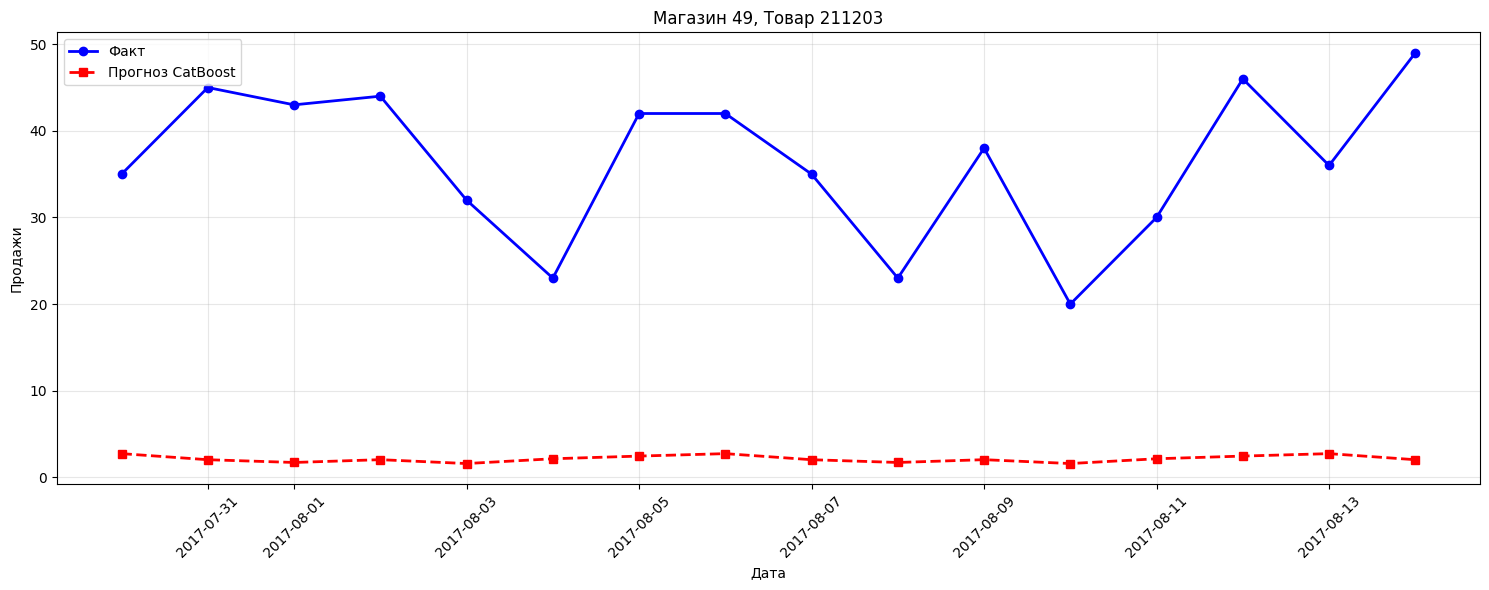

In [ ]:
example_store, example_item = 49, 211203
example_data = val_with_pred[
    (val_with_pred['store_nbr'] == example_store) & 
    (val_with_pred['item_nbr'] == example_item)
].sort_values('date')

if len(example_data) > 0:
    plt.figure(figsize=(15, 6))
    plt.plot(example_data['date'], example_data['unit_sales'], 'b-', label='Факт', linewidth=2, marker='o')
    plt.plot(example_data['date'], example_data['predicted'], 'r--', label='Прогноз AutoETS', linewidth=2, marker='s')
    plt.title(f'Магазин {example_store}, Товар {example_item}')
    plt.xlabel('Дата')
    plt.ylabel('Продажи')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()